# 1. Environment Setup and Data Loading

In [1]:
#  Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi'        : 130,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F9FA',
    'axes.grid'         : True,
    'grid.alpha'        : 0.35,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'serif',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'axes.titleweight'  : 'bold',
})

# Colour system
BLUE   = '#2E5FA3'
NAVY   = '#1A2D5A'
GREEN  = '#276749'
ORANGE = '#C05621'
RED    = '#9B2335'
GRAY   = '#718096'
PALETTE = [BLUE, GREEN, ORANGE, RED]

print('Libraries loaded')
for lib, mod in [('pandas', pd), ('numpy', np), ('scipy', stats), ('seaborn', sns)]:
    ver = getattr(mod, '__version__', 'N/A')
    print(f'   {lib}: {ver}')

Libraries loaded
   pandas: 2.3.3
   numpy: 2.3.5
   scipy: N/A
   seaborn: 0.13.2


In [2]:
# Data Loading
DATA_PATH = 'recruitment_efficiency_improved.csv'

df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('── Schema')
print(df.dtypes)
print()
print('── First 5 rows')
df.head()

Dataset loaded: recruitment_efficiency_improved.csv
Shape: 5,000 rows × 8 columns

── Schema
recruitment_id             int64
department                object
job_title                 object
num_applicants             int64
time_to_hire_days          int64
cost_per_hire            float64
source                    object
offer_acceptance_rate    float64
dtype: object

── First 5 rows


,recruitment_id,department,job_title,num_applicants,time_to_hire_days,cost_per_hire,source,offer_acceptance_rate
0,1,Engineering,Software Engineer,280,24,1400.38,Referral,0.98
1,2,Sales,Account Executive,262,7,2730.45,LinkedIn,0.84
2,3,Product,UX Designer,11,76,5286.12,LinkedIn,0.83
3,4,Engineering,DevOps Engineer,238,26,5255.78,Recruiter,0.49
4,5,HR,Talent Acquisition,275,37,4987.03,LinkedIn,0.79


# 2. Data Quality Assessment

In [3]:
# 2a. Missing Values
missing = df.isnull().sum()
print("[Missing Values]")
print(missing[missing > 0] if missing.any() else "No missing values found.")
# Decision: dataset is clean — no imputation needed

# 2b. Duplicates
dupes = df.duplicated().sum()
print(f"\n[Duplicates] {dupes} duplicate rows found.")
if dupes:
    df = df.drop_duplicates()
    print(f"  → Removed {dupes} duplicates. Remaining rows: {len(df):,}")

# 2c. Outlier Analysis (IQR method)
numeric_cols = ['num_applicants', 'time_to_hire_days', 'cost_per_hire', 'offer_acceptance_rate']
print("\n[Outlier Analysis — IQR Method]")
outlier_summary = {}
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'lower_fence': lo, 'upper_fence': hi,
                             'n_outliers': n_out,
                             'pct': round(n_out / len(df) * 100, 2)}
    print(f"  {col:30s} → {n_out:4d} outliers ({outlier_summary[col]['pct']}%)")

# 2d. Anomaly / Sanity Checks
print("\n[Sanity Checks]")
assert (df['offer_acceptance_rate'] >= 0).all() and \
       (df['offer_acceptance_rate'] <= 1).all(), "Rate out of [0,1]!"
assert (df['time_to_hire_days'] > 0).all(), "Negative hire time!"
assert (df['cost_per_hire'] > 0).all(), "Negative cost!"
assert (df['num_applicants'] > 0).all(), "Zero applicants!"
print("All domain constraints satisfied.")

[Missing Values]
No missing values found.

[Duplicates] 0 duplicate rows found.

[Outlier Analysis — IQR Method]
  num_applicants                 →    0 outliers (0.0%)
  time_to_hire_days              →    0 outliers (0.0%)
  cost_per_hire                  →    0 outliers (0.0%)
  offer_acceptance_rate          →    0 outliers (0.0%)

[Sanity Checks]
All domain constraints satisfied.


── Outlier overview
Feature                       IQR Lower  IQR Upper  IQR Outliers  Z>3 Outliers
--------------------------------------------------------------------------------
  num_applicants                  -136.00     448.00             0             0
  time_to_hire_days                -35.50     128.50             0             0
  cost_per_hire                  -4365.63   14797.64             0             0
  offer_acceptance_rate             -0.04       1.35             0             0


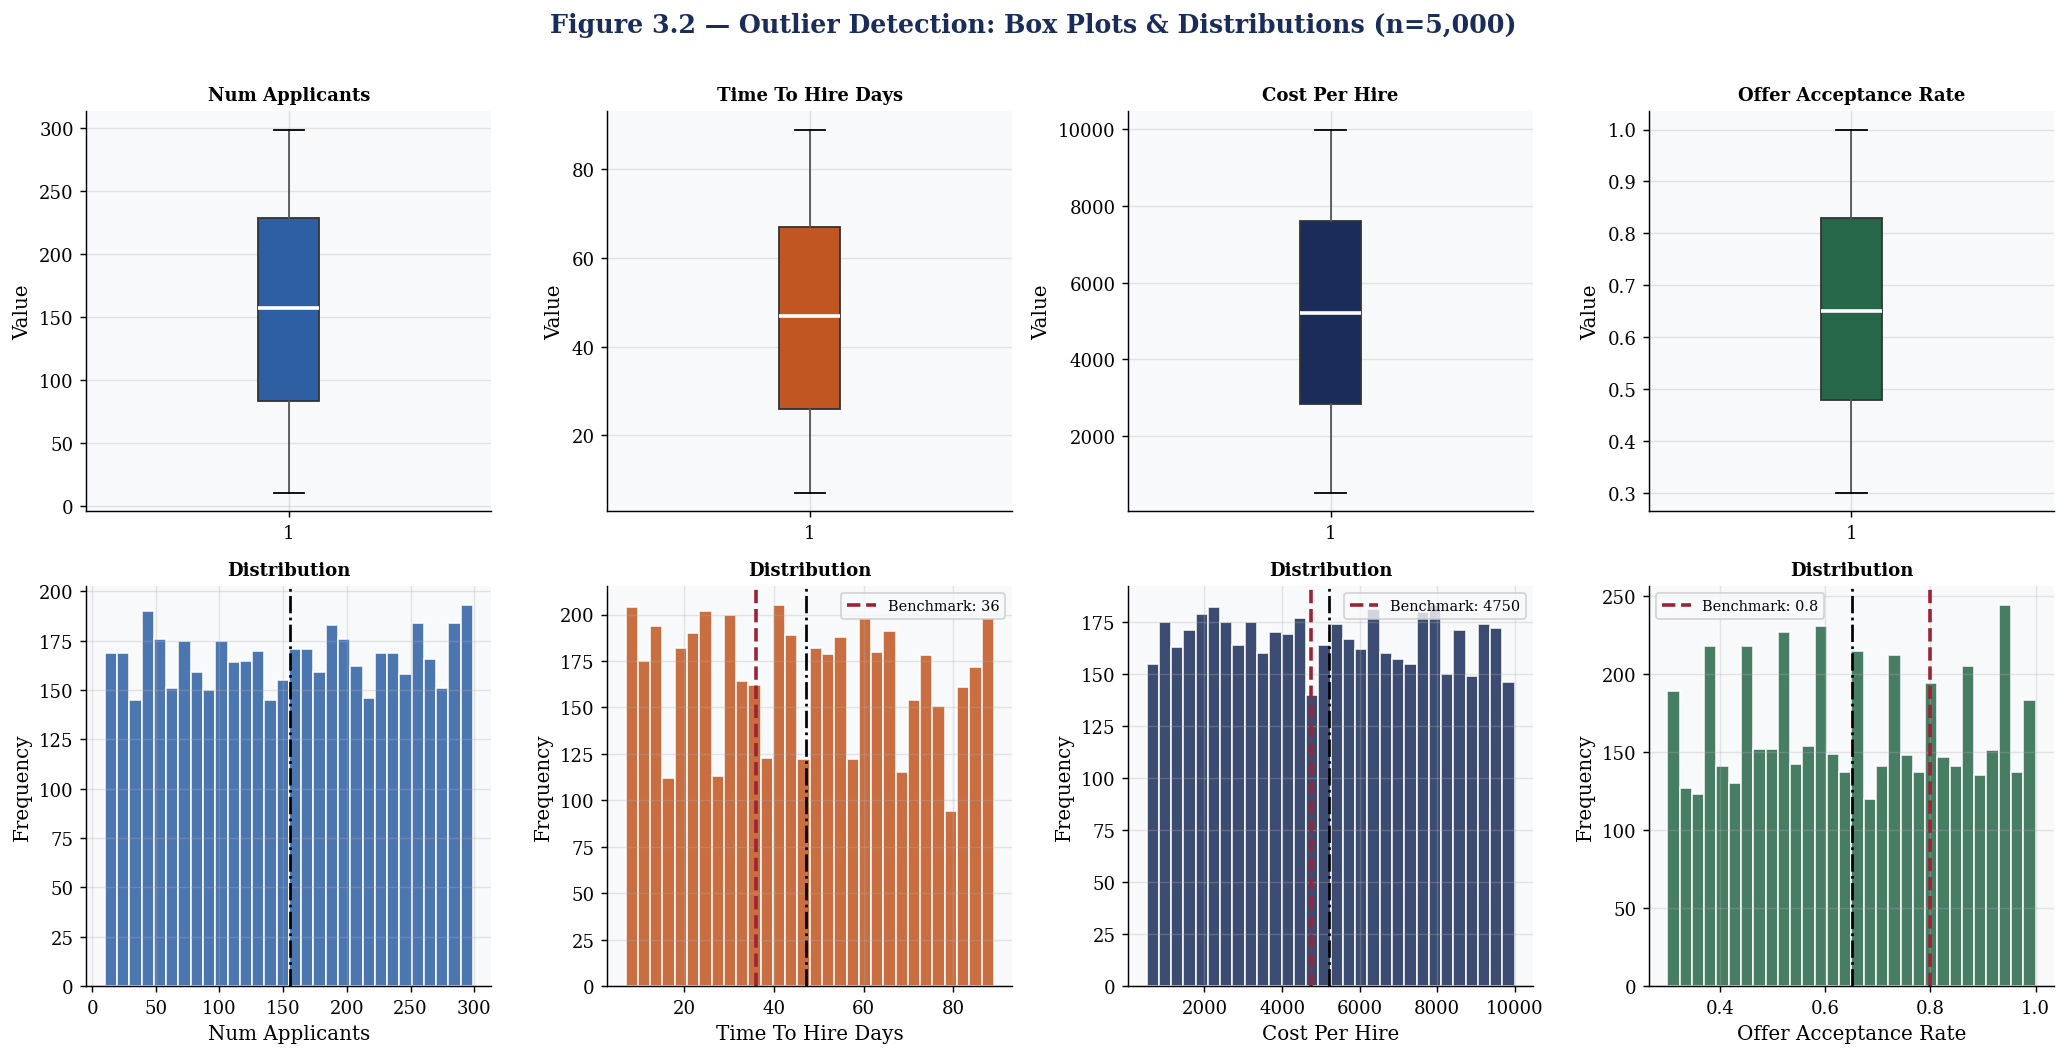

Verdict: No statistical outliers detected by either IQR or Z-score method.
All values are within operationally plausible ranges.
Action: No capping, flooring, or removal applied.
Note: Near-uniform distributions explain the wide IQR bounds — this is a dataset
      characteristic, not an outlier problem. See Section 4 for distributional analysis.


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
num_cols    = ['num_applicants', 'time_to_hire_days', 'cost_per_hire', 'offer_acceptance_rate']
colors_list = [BLUE, ORANGE, NAVY, GREEN]
BENCHMARKS = {
    'time_to_hire_days': 36,
    'cost_per_hire': 4750,
    'offer_acceptance_rate': 0.80
}

print("── Outlier overview")
print(f"{'Feature':<28} {'IQR Lower':>10} {'IQR Upper':>10} {'IQR Outliers':>13} {'Z>3 Outliers':>13}")
print("-" * 80)

for i, (col, color) in enumerate(zip(num_cols, colors_list)):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    iqr_out = ((df[col] < lower) | (df[col] > upper)).sum()
    z_out   = (np.abs(stats.zscore(df[col])) > 3).sum()
    print(f"  {col:<28} {lower:>10.2f} {upper:>10.2f} {iqr_out:>13} {z_out:>13}")

    # Box plot (top row)
    axes[0, i].boxplot(df[col], patch_artist=True,
                       boxprops    =dict(facecolor=color, color='#333'),
                       medianprops =dict(color='white', linewidth=2),
                       whiskerprops=dict(color='#555'),
                       flierprops  =dict(marker='o', color=RED, markersize=3))
    axes[0, i].set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=10)
    axes[0, i].set_ylabel('Value')
    axes[0, i].grid(axis='y', alpha=0.3)

    # Histogram (bottom row)
    axes[1, i].hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    if col in BENCHMARKS:
        axes[1, i].axvline(BENCHMARKS[col], color=RED, lw=2, ls='--',
                           label=f'Benchmark: {BENCHMARKS[col]}')
        axes[1, i].legend(fontsize=8)
    axes[1, i].axvline(df[col].mean(), color='black', lw=1.5, ls='-.',
                       label=f'Mean: {df[col].mean():.2f}')
    axes[1, i].set_title('Distribution', fontsize=10)
    axes[1, i].set_xlabel(col.replace('_', ' ').title())
    axes[1, i].set_ylabel('Frequency')
    axes[1, i].grid(alpha=0.3)

plt.suptitle('Figure 3.2 — Outlier Detection: Box Plots & Distributions (n=5,000)',
             fontsize=14, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.savefig('fig_3_2_outlier_detection.png', dpi=110, bbox_inches='tight')
plt.show()

print("Verdict: No statistical outliers detected by either IQR or Z-score method.")
print("All values are within operationally plausible ranges.")
print("Action: No capping, flooring, or removal applied.")
print("Note: Near-uniform distributions explain the wide IQR bounds — this is a dataset")
print("      characteristic, not an outlier problem. See Section 4 for distributional analysis.")

In [4]:
# Category Inventory
print('Categorical Features')
for col in ['department', 'source', 'job_title']:
    counts = df[col].value_counts()
    print(f'\n── {col} ({len(counts)} unique)')
    for val, cnt in counts.items():
        print(f'  {val:<35} n={cnt:>4}  ({100*cnt/len(df):.1f}%)')

Categorical Features

── department (6 unique)
  HR                                  n= 871  (17.4%)
  Product                             n= 854  (17.1%)
  Finance                             n= 841  (16.8%)
  Sales                               n= 820  (16.4%)
  Marketing                           n= 811  (16.2%)
  Engineering                         n= 803  (16.1%)

── source (4 unique)
  LinkedIn                            n=1291  (25.8%)
  Referral                            n=1279  (25.6%)
  Recruiter                           n=1221  (24.4%)
  Job Portal                          n=1209  (24.2%)

── job_title (24 unique)
  HR Coordinator                      n= 238  (4.8%)
  Financial Analyst                   n= 234  (4.7%)
  UX Designer                         n= 233  (4.7%)
  HR Manager                          n= 223  (4.5%)
  Product Analyst                     n= 221  (4.4%)
  Social Media Manager                n= 217  (4.3%)
  Marketing Specialist                n= 217  (

In [5]:
# Numeric Range Validation
print('Full descriptive statistics:')
df.describe().round(3)

Full descriptive statistics:


,recruitment_id,num_applicants,time_to_hire_days,cost_per_hire,offer_acceptance_rate
count,5000.00,5000.000,5000.000,5000.000,5000.000
mean,2500.50,155.621,47.191,5214.826,0.651
std,1443.52,84.164,23.865,2730.999,0.202
min,1.00,10.000,7.000,507.160,0.300
25%,1250.75,83.000,26.000,2820.598,0.480
50%,2500.50,157.000,47.000,5218.290,0.650
75%,3750.25,229.000,67.000,7611.412,0.830
max,5000.00,299.000,89.000,9998.910,1.000


# 3. Headline KPI Calculations

In [6]:
# Time-to-Hire Metrics
avg_tth = df['time_to_hire_days'].mean()
med_tth = df['time_to_hire_days'].median()
std_tth = df['time_to_hire_days'].std()

fast_n   = (df['time_to_hire_days'] < 30).sum()
mid_n    = ((df['time_to_hire_days'] >= 30) & (df['time_to_hire_days'] <= 45)).sum()
slow_n   = (df['time_to_hire_days'] > 45).sum()
fast_pct = fast_n / len(df) * 100
mid_pct  = mid_n  / len(df) * 100
slow_pct = slow_n / len(df) * 100

# Cost-per-Hire Metrics
avg_cph       = df['cost_per_hire'].mean()
med_cph       = df['cost_per_hire'].median()
std_cph       = df['cost_per_hire'].std()
cv_cph        = std_cph / avg_cph * 100     # Coefficient of Variation (internal target: <25-30%)
high_cost_n   = (df['cost_per_hire'] > 7500).sum()
high_cost_pct = high_cost_n / len(df) * 100

# Offer Acceptance Rate
avg_oar = df['offer_acceptance_rate'].mean()
med_oar = df['offer_acceptance_rate'].median()
std_oar = df['offer_acceptance_rate'].std()

# Segmentation
high_n = (df['offer_acceptance_rate'] >= 0.80).sum()
mid2_n = ((df['offer_acceptance_rate'] >= 0.70) & (df['offer_acceptance_rate'] < 0.80)).sum()
low_n  = (df['offer_acceptance_rate'] < 0.70).sum()

# Print Report
print('Headline KPI Summary — Recruitment Efficiency Dataset')
print(f'\n  Time-to-Hire')
print(f'    Mean           : {avg_tth:.2f} days')
print(f'    Median         : {med_tth:.1f} days')
print(f'    Std Dev        : {std_tth:.2f} days')
print(f'    SHRM Benchmark : 36 days  🟢 Industry benchmark (LinkedIn’s 2024-2025 recruitment report, 2025)')
print(f'    Gap            : +{avg_tth-36:.1f} days above 36-day target')
print(f'    < 30 days      : {fast_n:,} ({fast_pct:.1f}%)')
print(f'    30–45 days     : {mid_n:,} ({mid_pct:.1f}%)')
print(f'    > 45 days      : {slow_n:,} ({slow_pct:.1f}%)')
print(f'\n  Cost-per-Hire')
print(f'    Mean           : ${avg_cph:,.2f}')
print(f'    Median         : ${med_cph:,.2f}')
print(f'    Std Dev        : ${std_cph:,.2f}')
print(f'    CV             : {cv_cph:.1f}%          🟡 Statistical rule-of-thumb: <25–30% = acceptable')
print(f'    SHRM Benchmark : $4,700–$4,800  🟢 Industry benchmark (SHRM, 2025)')
print(f'    High-cost >$7,500: {high_cost_n:,} ({high_cost_pct:.1f}%)')
print(f'\n  Offer Acceptance Rate')
print(f'    Mean           : {avg_oar:.4f} ({avg_oar*100:.1f}%)')
print(f'    Median         : {med_oar:.3f}')
print(f'    Industry Bench : 80–90%  🟢 Industry benchmark (Ashby 2024)')
print(f'    OAR Red Flag   : <70%    🟢 Industry threshold (KPI Depot)')
print(f'    High (>=80%)   : {high_n:,} ({100*high_n/len(df):.1f}%)')
print(f'    Mid (70–79%)   : {mid2_n:,} ({100*mid2_n/len(df):.1f}%)')
print(f'    Low (<70%)     : {low_n:,} ({100*low_n/len(df):.1f}%) ')

Headline KPI Summary — Recruitment Efficiency Dataset

  Time-to-Hire
    Mean           : 47.19 days
    Median         : 47.0 days
    Std Dev        : 23.86 days
    SHRM Benchmark : 36 days  🟢 Industry benchmark (LinkedIn’s 2024-2025 recruitment report, 2025)
    Gap            : +11.2 days above 36-day target
    < 30 days      : 1,434 (28.7%)
    30–45 days     : 981 (19.6%)
    > 45 days      : 2,585 (51.7%)

  Cost-per-Hire
    Mean           : $5,214.83
    Median         : $5,218.29
    Std Dev        : $2,731.00
    CV             : 52.4%          🟡 Statistical rule-of-thumb: <25–30% = acceptable
    SHRM Benchmark : $4,700–$4,800  🟢 Industry benchmark (SHRM, 2025)
    High-cost >$7,500: 1,311 (26.2%)

  Offer Acceptance Rate
    Mean           : 0.6508 (65.1%)
    Median         : 0.650
    Industry Bench : 80–90%  🟢 Industry benchmark (Ashby 2024)
    OAR Red Flag   : <70%    🟢 Industry threshold (KPI Depot)
    High (>=80%)   : 1,468 (29.4%)
    Mid (70–79%)   : 707 (14.1

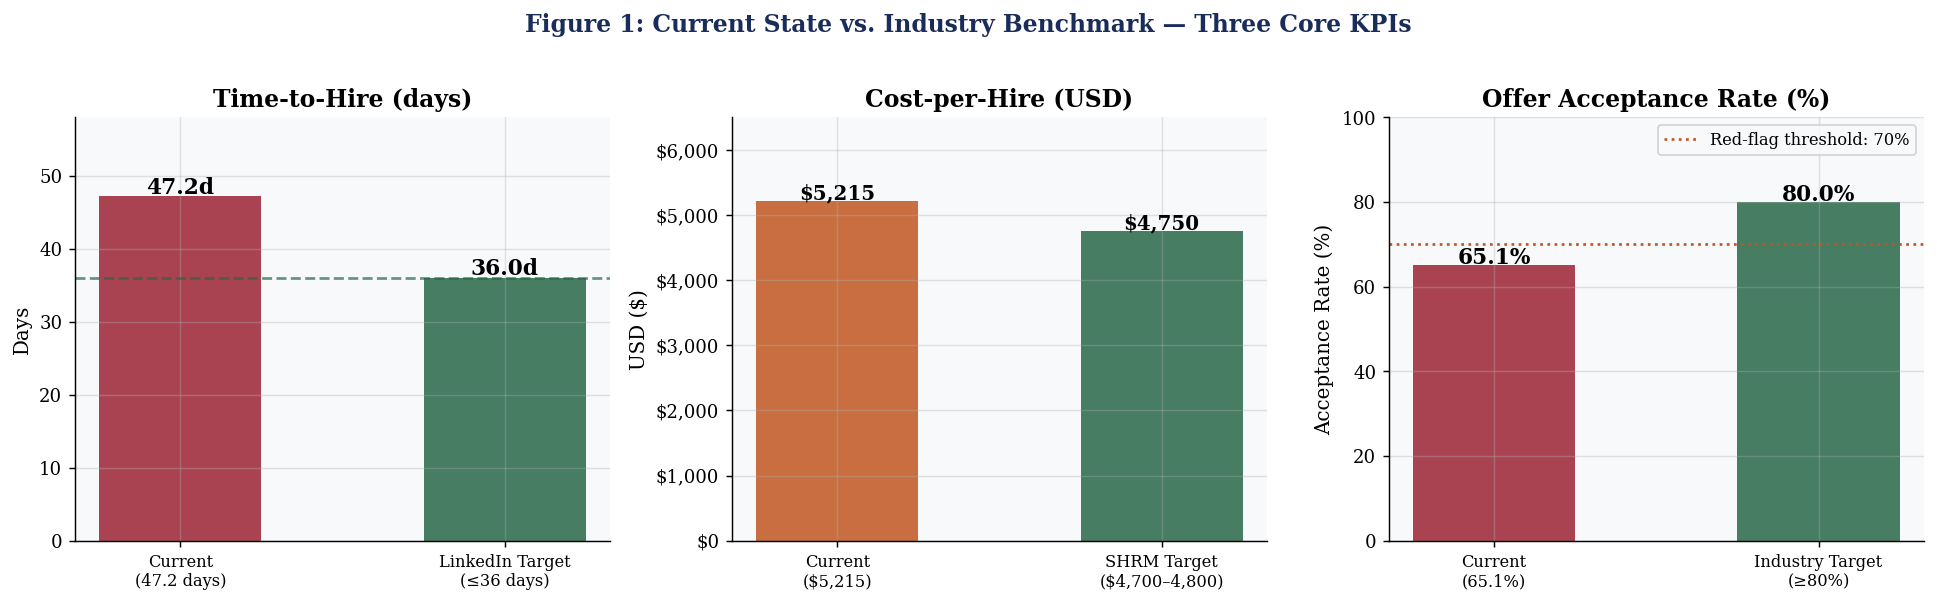

In [7]:
# KPI Dashboard Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Figure 1: Current State vs. Industry Benchmark — Three Core KPIs',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)

# Time-to-hire
ax = axes[0]
vals  = [avg_tth, 36]
labs  = ['Current\n(47.2 days)', 'LinkedIn Target\n(≤36 days)']
cols  = [RED, GREEN]
bars  = ax.bar(labs, vals, color=cols, alpha=0.85, width=0.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.4,
            f'{v:.1f}d', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Time-to-Hire (days)'); ax.set_ylim(0, 58)
ax.set_ylabel('Days')
ax.axhline(36, color=GREEN, linestyle='--', lw=1.5, alpha=0.7)

# Cost-per-hire
ax = axes[1]
vals  = [avg_cph, 4750]
labs  = ['Current\n($5,215)', 'SHRM Target\n($4,700–4,800)']
bars  = ax.bar(labs, vals, color=[ORANGE, GREEN], alpha=0.85, width=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+30,
            f'${v:,.0f}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Cost-per-Hire (USD)'); ax.set_ylim(0, 6500)
ax.set_ylabel('USD ($)')

# Offer acceptance rate
ax = axes[2]
vals  = [avg_oar*100, 80]
labs  = ['Current\n(65.1%)', 'Industry Target\n(≥80%)']
bars  = ax.bar(labs, vals, color=[RED, GREEN], alpha=0.85, width=0.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.4,
            f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Offer Acceptance Rate (%)')
ax.set_ylabel('Acceptance Rate (%)')
ax.set_ylim(0, 100)
ax.axhline(70, color=ORANGE, linestyle=':', lw=1.5, label='Red-flag threshold: 70%')
ax.legend(fontsize=9)

for a in axes:
    a.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('fig1_kpi_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

# 4. Time-to-Hire Analysis

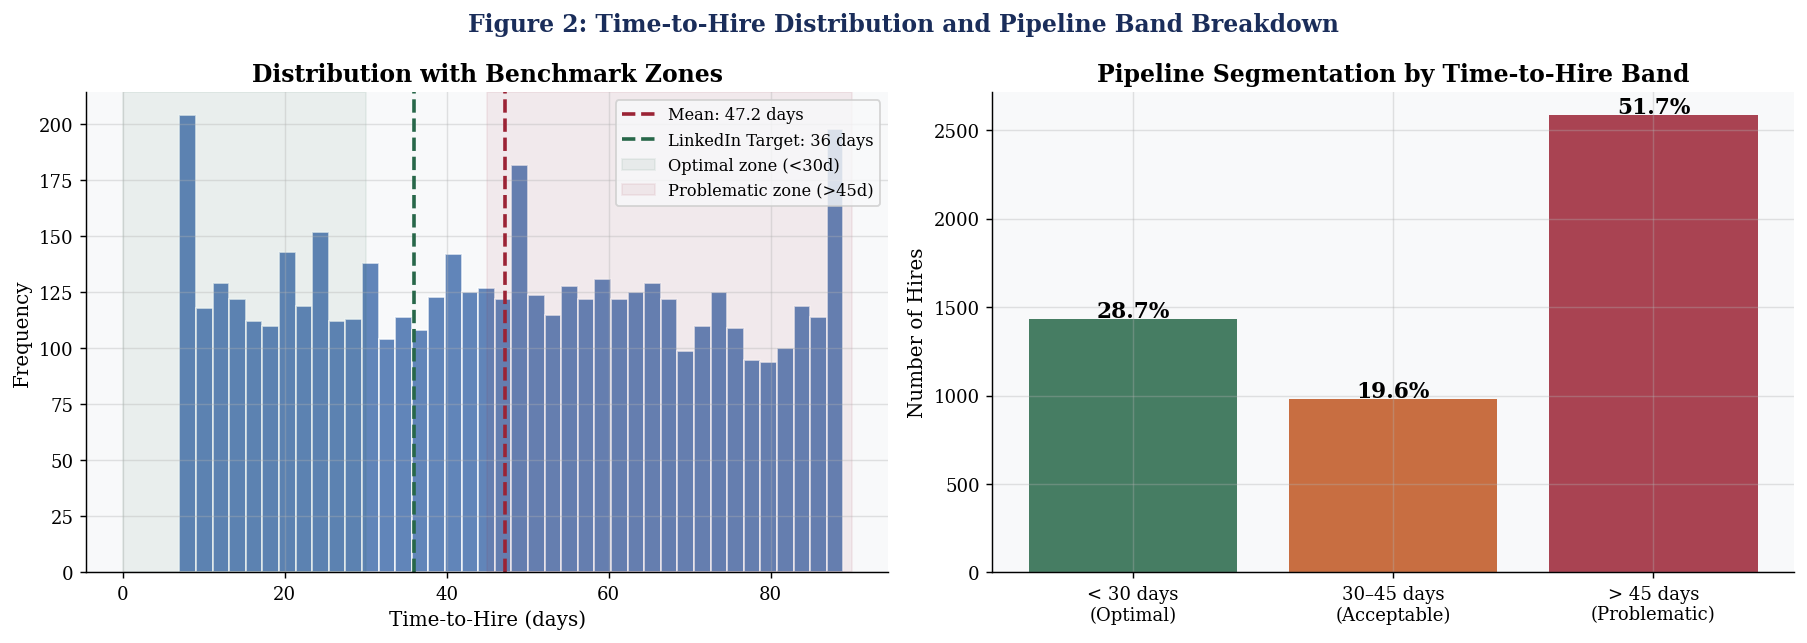

KEY FINDING: 51.7% of hires (2,585) exceed the 45-day ceiling.
Only 28.7% achieve the optimal sub-30-day target.


In [8]:
# Time-to-Hire Distribution with Benchmark Overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 2: Time-to-Hire Distribution and Pipeline Band Breakdown',
             fontsize=13, fontweight='bold', color=NAVY)

ax = axes[0]
ax.hist(df['time_to_hire_days'], bins=40, color=BLUE, alpha=0.75, edgecolor='white')
ax.axvline(avg_tth, color=RED, lw=2, linestyle='--', label=f'Mean: {avg_tth:.1f} days')
ax.axvline(36,      color=GREEN, lw=2, linestyle='--', label='LinkedIn Target: 36 days')
ax.axvspan(0,  30, alpha=0.07, color=GREEN, label='Optimal zone (<30d)')
ax.axvspan(45, df['time_to_hire_days'].max()+1, alpha=0.07, color=RED, label='Problematic zone (>45d)')
ax.set_xlabel('Time-to-Hire (days)'); ax.set_ylabel('Frequency')
ax.set_title('Distribution with Benchmark Zones')
ax.legend(fontsize=9)

ax = axes[1]
bands  = ['< 30 days\n(Optimal)', '30–45 days\n(Acceptable)', '> 45 days\n(Problematic)']
counts = [fast_n, mid_n, slow_n]
pcts   = [fast_pct, mid_pct, slow_pct]
clrs   = [GREEN, ORANGE, RED]
bars   = ax.bar(bands, counts, color=clrs, alpha=0.85)
for b, p in zip(bars, pcts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+10,
            f'{p:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Hires')
ax.set_title('Pipeline Segmentation by Time-to-Hire Band')

plt.tight_layout()
plt.savefig('fig2_time_to_hire.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'KEY FINDING: {slow_pct:.1f}% of hires ({slow_n:,}) exceed the 45-day ceiling.')
print(f'Only {fast_pct:.1f}% achieve the optimal sub-30-day target.')

── Time-to-Hire by Department
              mean  median    std  count
department                              
Finance      48.21    48.0  23.68    841
Engineering  47.88    49.0  24.10    803
Marketing    47.83    48.0  23.73    811
Sales        47.31    47.0  24.06    820
Product      46.26    45.0  24.16    854
HR           45.78    45.0  23.45    871


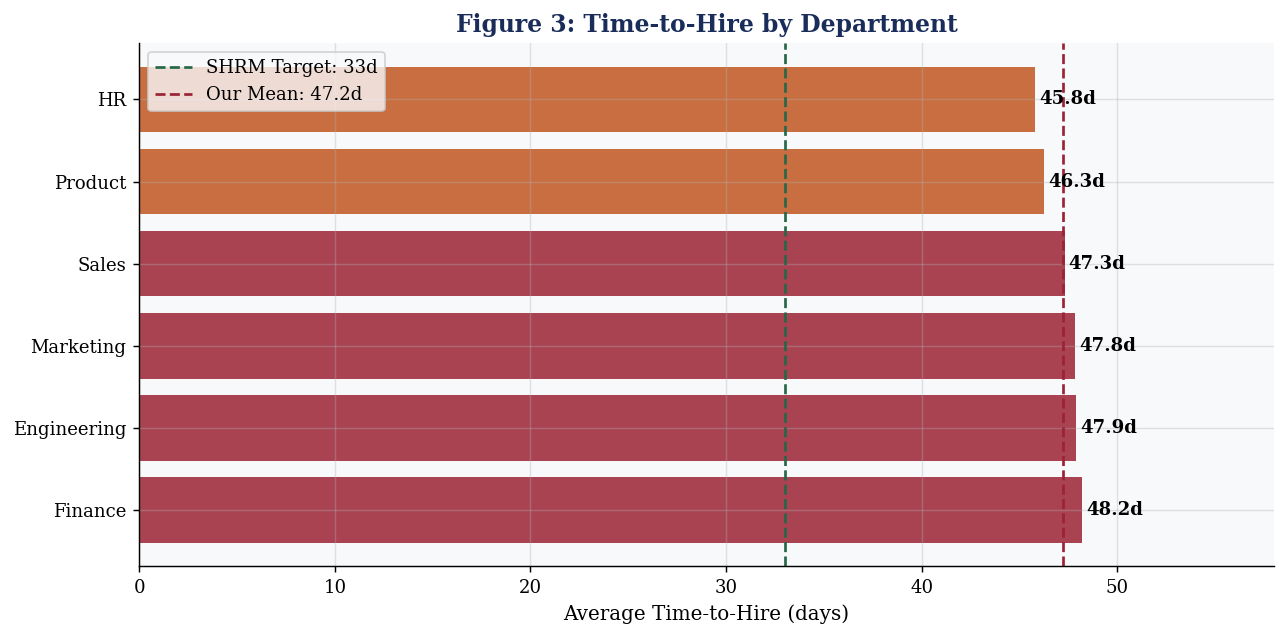

Slowest department: Finance at 48.2 days avg.


In [9]:
# Time-to-Hire by Department
dept_tth = (df.groupby('department')['time_to_hire_days']
             .agg(['mean','median','std','count'])
             .round(2).sort_values('mean', ascending=False))
avg_time_to_hire = df['time_to_hire_days'].mean()
print('── Time-to-Hire by Department')
print(dept_tth)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [
    RED    if v > 47 else
    ORANGE if v > 45 else
    GREEN
    for v in dept_tth['mean']
]

bars = ax.barh(dept_tth.index, dept_tth['mean'], color=colors, alpha=0.85)

ax.axvline(33, color=GREEN, linestyle='--', linewidth=1.5, label='SHRM Target: 33d')
ax.axvline(avg_time_to_hire, color=RED, linestyle='--',
           linewidth=1.5, label=f'Our Mean: {avg_time_to_hire:.1f}d')

for bar in bars:
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}d',
        va='center', fontsize=10, fontweight='bold'
    )

ax.set_xlabel('Average Time-to-Hire (days)')
ax.set_title('Figure 3: Time-to-Hire by Department', fontweight='bold', color=NAVY) 
ax.legend()
ax.set_xlim(0, 58)

plt.tight_layout()
plt.savefig('fig3_time_dept.png', bbox_inches='tight', dpi=150)
plt.show()

worst_dept = dept_tth['mean'].idxmax()
print(f'Slowest department: {worst_dept} at {dept_tth["mean"].max():.1f} days avg.')

# 5. Cost-per-Hire Analysis

In [10]:
# Cost-per-Hire Distribution and IQR Outlier Analysis
q1  = df['cost_per_hire'].quantile(0.25)
q3  = df['cost_per_hire'].quantile(0.75)
iqr = q3 - q1
outliers = df[(df['cost_per_hire'] < q1-1.5*iqr) | (df['cost_per_hire'] > q3+1.5*iqr)]

print('── Cost-per-Hire Statistics')
print(f'  Mean              : ${avg_cph:,.2f}')
print(f'  Median            : ${med_cph:,.2f}')
print(f'  Std Dev           : ${std_cph:,.2f}')
print(f'  Min / Max         : ${df["cost_per_hire"].min():,.2f} / ${df["cost_per_hire"].max():,.2f}')
print(f'  Q1                : ${q1:,.2f}')
print(f'  Q3                : ${q3:,.2f}')
print(f'  IQR               : ${iqr:,.2f}')
print(f'  IQR Outliers      : {len(outliers)} records')
print(f'  CV (SD/Mean×100)  : {cv_cph:.1f}%')
print(f'  High-cost >$7,500 : {high_cost_n:,} ({high_cost_pct:.1f}%)')
print()
print(f'  🟡 CV target: <25–30% (statistical rule-of-thumb; ScienceDirect, 2023)')
print(f'  🟢 CPH benchmark: $4,700–$4,800 (SHRM, 2025)')
print(f'  Gap vs SHRM: +${avg_cph-4750:,.0f} per hire over mid-benchmark')

── Cost-per-Hire Statistics
  Mean              : $5,214.83
  Median            : $5,218.29
  Std Dev           : $2,731.00
  Min / Max         : $507.16 / $9,998.91
  Q1                : $2,820.60
  Q3                : $7,611.41
  IQR               : $4,790.82
  IQR Outliers      : 0 records
  CV (SD/Mean×100)  : 52.4%
  High-cost >$7,500 : 1,311 (26.2%)

  🟡 CV target: <25–30% (statistical rule-of-thumb; ScienceDirect, 2023)
  🟢 CPH benchmark: $4,700–$4,800 (SHRM, 2025)
  Gap vs SHRM: +$465 per hire over mid-benchmark


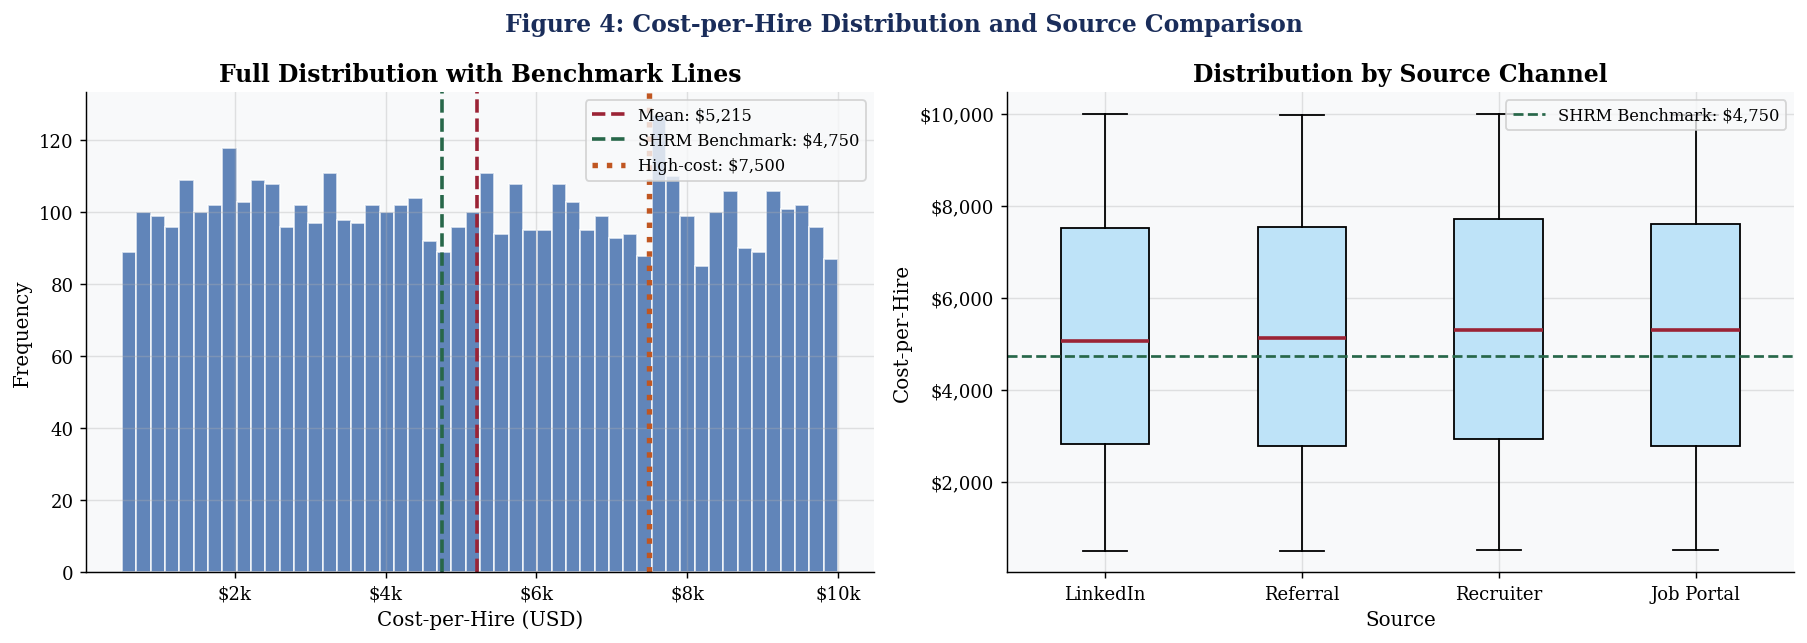

FINDING: CV = 52.4% — exceeds the "very high" variability classification (>50%).
No source channel is systematically cheaper, suggesting systemic cost drivers not channel-specific.


In [11]:
# Cost Visualisations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4: Cost-per-Hire Distribution and Source Comparison',
             fontsize=13, fontweight='bold', color=NAVY)

ax = axes[0]
ax.hist(df['cost_per_hire'], bins=50, color=BLUE, alpha=0.75, edgecolor='white')
ax.axvline(avg_cph, color=RED, lw=2, linestyle='--', label=f'Mean: ${avg_cph:,.0f}')
ax.axvline(4750, color=GREEN, lw=2, linestyle='--', label='SHRM Benchmark: $4,750')
ax.axvline(7500, color=ORANGE, lw=3, linestyle=':', label='High-cost: $7,500')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
ax.set_xlabel('Cost-per-Hire (USD)'); ax.set_ylabel('Frequency')
ax.set_title('Full Distribution with Benchmark Lines')
ax.legend(fontsize=9)

ax = axes[1]
src_order = df.groupby('source')['cost_per_hire'].median().sort_values().index
src_data  = [df.loc[df['source']==s, 'cost_per_hire'].values for s in src_order]
bp = ax.boxplot(src_data, labels=src_order, patch_artist=True,
           medianprops=dict(color=RED, linewidth=2),
           flierprops=dict(marker='.', color=ORANGE, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#BEE3F8')
ax.axhline(4750, color=GREEN, linestyle='--', lw=1.5, label='SHRM Benchmark: $4,750')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Distribution by Source Channel')
ax.set_xlabel('Source'); ax.set_ylabel('Cost-per-Hire')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('fig4_cost_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'FINDING: CV = {cv_cph:.1f}% — exceeds the "very high" variability classification (>50%).')
print('No source channel is systematically cheaper, suggesting systemic cost drivers not channel-specific.')

# 6. Offer Acceptance Rate Analysis

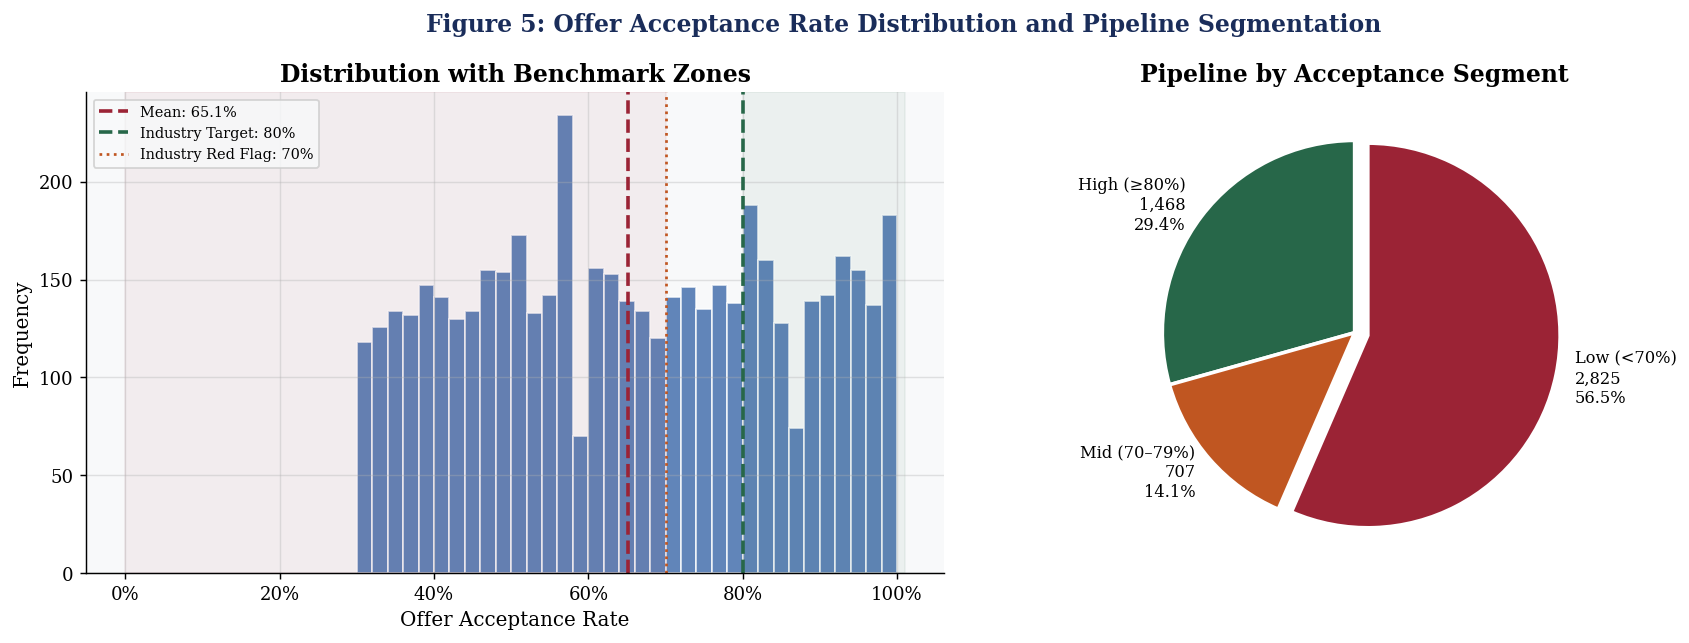

FINDING: 56.5% of pipeline falls in the 70%.
         Our mean OAR of 65.1% is below the <70% industry red-flag threshold.


In [12]:
# Acceptance Rate Distribution and Segmentation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 5: Offer Acceptance Rate Distribution and Pipeline Segmentation',
             fontsize=13, fontweight='bold', color=NAVY)

ax = axes[0]
ax.hist(df['offer_acceptance_rate'], bins=35, color=BLUE, alpha=0.75, edgecolor='white')
ax.axvline(avg_oar, color=RED, lw=2, linestyle='--', label=f'Mean: {avg_oar*100:.1f}%')
ax.axvline(0.80, color=GREEN, lw=2, linestyle='--', label='Industry Target: 80%')
ax.axvline(0.70, color=ORANGE, lw=1.5, linestyle=':', label='Industry Red Flag: 70%')
ax.axvspan(0, 0.70, alpha=0.06, color=RED)
ax.axvspan(0.80, 1.01, alpha=0.06, color=GREEN)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax.set_xlabel('Offer Acceptance Rate'); ax.set_ylabel('Frequency')
ax.set_title('Distribution with Benchmark Zones')
ax.legend(fontsize=8)

ax = axes[1]
segs   = [f'High (≥80%)\n{high_n:,}\n{100*high_n/len(df):.1f}%',
           f'Mid (70–79%)\n{mid2_n:,}\n{100*mid2_n/len(df):.1f}%',
           f'Low (<70%)\n{low_n:,}\n{100*low_n/len(df):.1f}%']
sizes  = [high_n, mid2_n, low_n]
clrs   = [GREEN, ORANGE, RED]
ax.pie(sizes, labels=segs, colors=clrs, startangle=90,
       explode=(0,0,0.07), textprops={'fontsize':9},
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Pipeline by Acceptance Segment')

plt.tight_layout()
plt.savefig('fig5_acceptance_rate.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'FINDING: {100*low_n/len(df):.1f}% of pipeline falls in the 70%.')
print(f'         Our mean OAR of {avg_oar*100:.1f}% is below the <70% industry red-flag threshold.')

# 7. Source Channel Performance

── Source Channel Performance Matrix
            count  share_pct  avg_time  avg_cost  oar_pct  avg_applicants
source                                                                   
Job Portal   1209      24.18     46.51   5248.67     65.0          157.54
LinkedIn     1291      25.82     46.99   5148.31     65.0          154.99
Recruiter    1221      24.42     47.41   5303.15     66.0          153.99
Referral     1279      25.58     47.83   5165.65     65.0          156.00

  OAR range across sources  : 1.0 percentage points
  Time range across sources : 1.3 days
  Cost range across sources : $155

  DIAGNOSTIC FINDING: Near-identical performance across all four channels.
  Root cause is systemic (role/department/offer) not channel-specific.


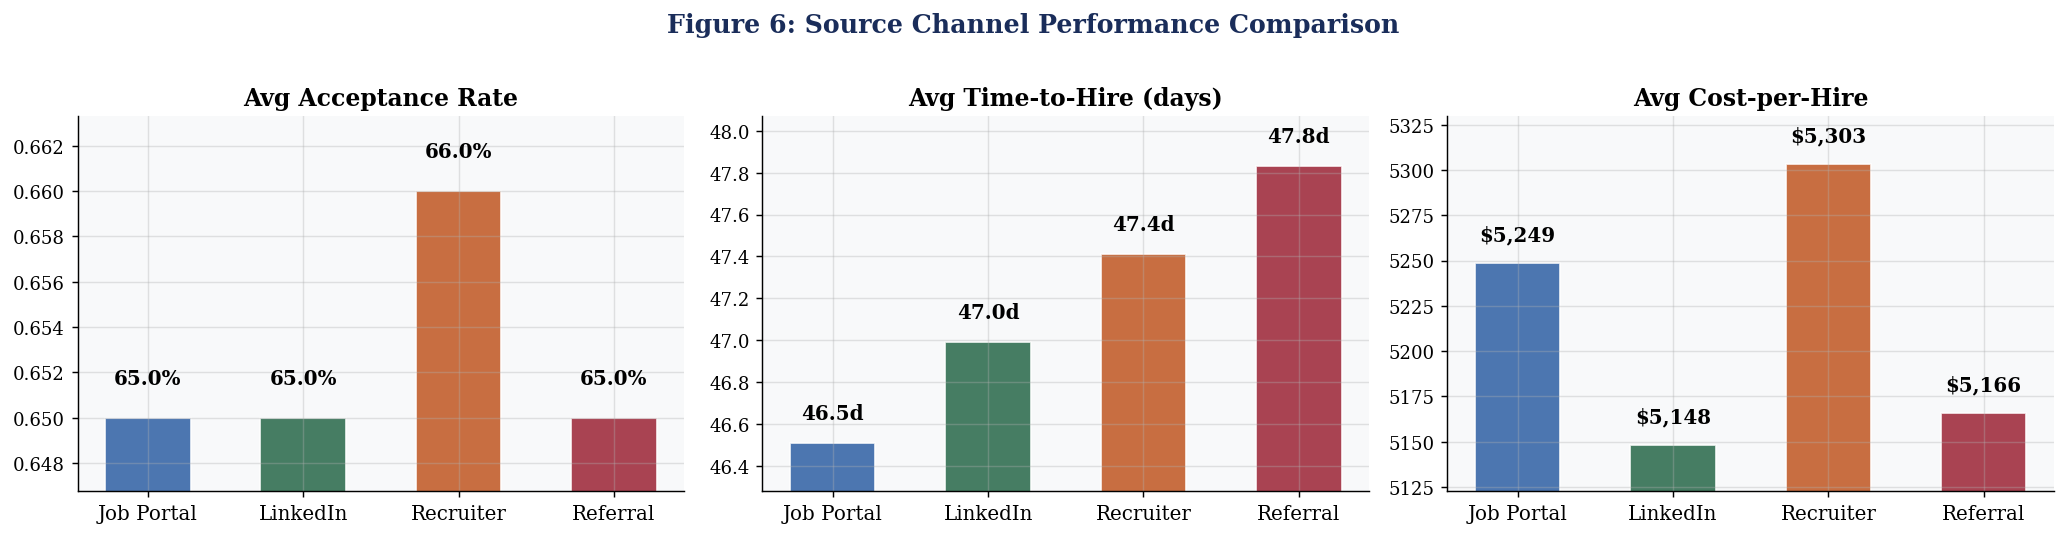

In [13]:
# Source Performance Matrix
src_perf = df.groupby('source').agg(
    count          = ('recruitment_id',       'count'),
    share_pct      = ('recruitment_id',       lambda x: len(x)/len(df)*100),
    avg_time       = ('time_to_hire_days',    'mean'),
    avg_cost       = ('cost_per_hire',        'mean'),
    avg_acceptance = ('offer_acceptance_rate','mean'),
    avg_applicants = ('num_applicants',       'mean'),
).round(2)
src_perf['oar_pct'] = (src_perf['avg_acceptance'] * 100).round(1)

print('── Source Channel Performance Matrix')
print(src_perf[['count','share_pct','avg_time','avg_cost','oar_pct','avg_applicants']])

oar_range  = src_perf['oar_pct'].max()  - src_perf['oar_pct'].min()
time_range = src_perf['avg_time'].max() - src_perf['avg_time'].min()
cost_range = src_perf['avg_cost'].max() - src_perf['avg_cost'].min()
print(f'\n  OAR range across sources  : {oar_range:.1f} percentage points')
print(f'  Time range across sources : {time_range:.1f} days')
print(f'  Cost range across sources : ${cost_range:,.0f}')
print(f'\n  DIAGNOSTIC FINDING: Near-identical performance across all four channels.')
print(f'  Root cause is systemic (role/department/offer) not channel-specific.')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Figure 6: Source Channel Performance Comparison',
             fontsize=14, fontweight='bold', color=NAVY, y=1.02)

metrics = [
    ('avg_acceptance', 'Avg Acceptance Rate',     '{:.1%}'.format),
    ('avg_time',       'Avg Time-to-Hire (days)', '{:.1f}d'.format),
    ('avg_cost',       'Avg Cost-per-Hire',       '${:,.0f}'.format),
]

sources = src_perf.index.tolist()
_base_colors = [BLUE, GREEN, ORANGE, RED, GRAY]
src_colors = [_base_colors[i % len(_base_colors)] for i in range(len(sources))]

for ax, (metric, label, fmt) in zip(axes, metrics):
    vals = src_perf[metric] 
    bars = ax.bar(sources, vals, color=src_colors, alpha=0.85, edgecolor='white', width=0.55)
    ax.set_title(label, fontweight='bold')
    ax.set_xticks(range(len(sources)))
    ax.set_xticklabels(sources, fontsize=11)

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.002,
            fmt(v),
            ha='center', va='bottom',
            fontweight='bold', fontsize=11,
            color='black'
        )

    ymin = vals.min() * 0.995
    ymax = vals.max() * 1.005
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.savefig('fig6_source_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

# 8.  Department and Job Title Analysis

In [14]:
# Department Performance Summary
dept = df.groupby('department').agg(
    count          = ('recruitment_id','count'),
    avg_time       = ('time_to_hire_days','mean'),
    avg_cost       = ('cost_per_hire','mean'),
    avg_acceptance = ('offer_acceptance_rate','mean'),
).round(2).sort_values('avg_acceptance')
dept['oar_%'] = (dept['avg_acceptance']*100).round(1)
print('── Department Performance (sorted by OAR ascending)')
print(dept[['count','avg_time','avg_cost','oar_%']])
print(f'\n  Critical department: Product — lowest OAR ({dept["oar_%"].min():.1f}%), highest[2] volume ({dept.loc['Product', 'count']:,}), and highest[2] cost ({dept.loc['Product', 'avg_cost']:,})')

── Department Performance (sorted by OAR ascending)
             count  avg_time  avg_cost  oar_%
department                                   
Product        854     46.26   5292.50   64.0
Sales          820     47.31   4983.70   64.0
Finance        841     48.21   5184.94   65.0
HR             871     45.78   5203.20   65.0
Engineering    803     47.88   5265.56   66.0
Marketing      811     47.83   5359.96   66.0

  Critical department: Product — lowest OAR (64.0%), highest[2] volume (854), and highest[2] cost (5,292.5)


── Department Performance (sorted by OAR ascending)
             count  avg_time  avg_cost  oar_%
department                                   
Product        854     46.26   5292.50   64.0
Sales          820     47.31   4983.70   64.0
Finance        841     48.21   5184.94   65.0
HR             871     45.78   5203.20   65.0
Engineering    803     47.88   5265.56   66.0
Marketing      811     47.83   5359.96   66.0

  Critical department: Product — lowest OAR (64.0%), count (854), avg cost ($5,292)


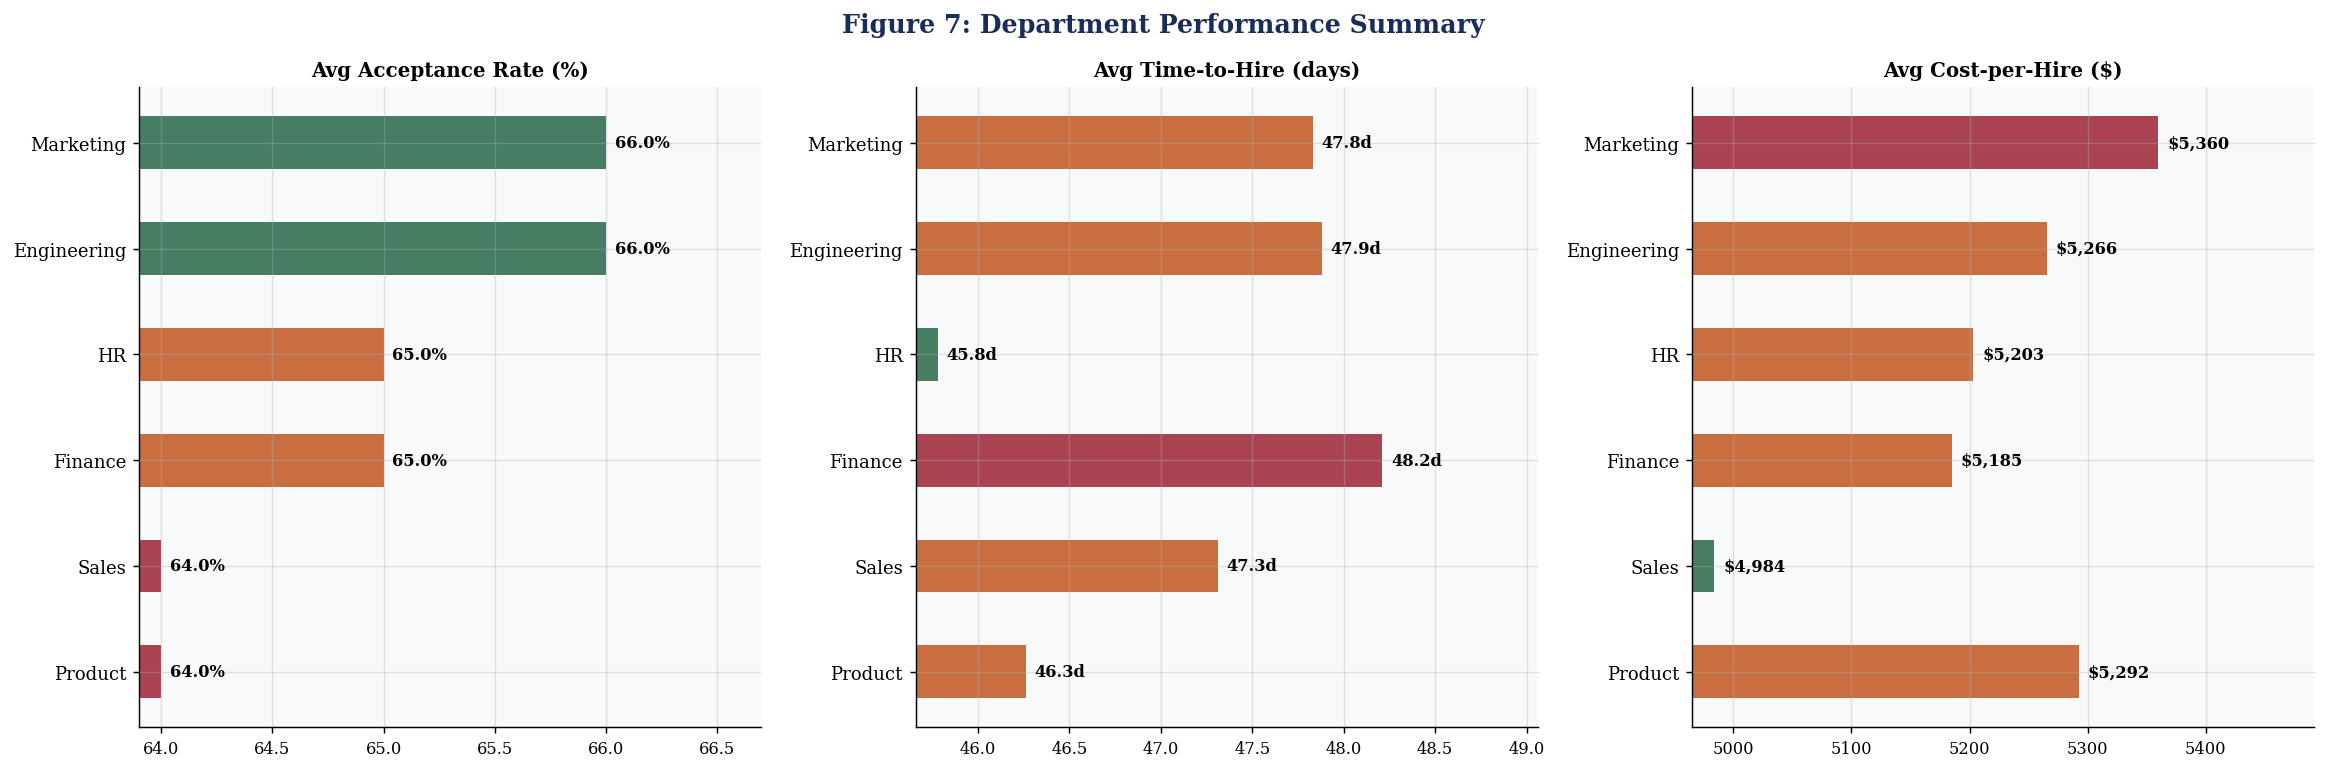

In [15]:
# Department Performance Summary
dept = df.groupby('department').agg(
    count          = ('recruitment_id',       'count'),
    avg_time       = ('time_to_hire_days',    'mean'),
    avg_cost       = ('cost_per_hire',        'mean'),
    avg_acceptance = ('offer_acceptance_rate','mean'),
).round(2).sort_values('avg_acceptance')
dept['oar_%'] = (dept['avg_acceptance'] * 100).round(1)

print('── Department Performance (sorted by OAR ascending)')
print(dept[['count', 'avg_time', 'avg_cost', 'oar_%']])

worst = dept['oar_%'].idxmin()
print(f'\n  Critical department: {worst} — '
      f'lowest OAR ({dept["oar_%"].min():.1f}%), '
      f'count ({dept.loc[worst, "count"]:,}), '
      f'avg cost (${dept.loc[worst, "avg_cost"]:,.0f})')

# ── Visualisation
avg_oar = df['offer_acceptance_rate'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 7: Department Performance Summary',
             fontsize=14, fontweight='bold', color=NAVY)

metrics = [
    ('oar_%',    'Avg Acceptance Rate (%)', '{:.1f}%',  False),  # low = bad
    ('avg_time', 'Avg Time-to-Hire (days)', '{:.1f}d',  True),   # ✅ high = bad
    ('avg_cost', 'Avg Cost-per-Hire ($)',   '${:,.0f}', True),   # ✅ high = bad
]

for ax, (col, label, fmt, invert) in zip(axes, metrics):
    vals = dept[col]

    if invert:
        colors_bar = [RED if v == vals.max() else GREEN if v == vals.min() else ORANGE
                      for v in vals]
    else:
        colors_bar = [RED if v == vals.min() else GREEN if v == vals.max() else ORANGE
                      for v in vals]

    bars = ax.barh(dept.index, vals, color=colors_bar, alpha=0.85, height=0.5)

    ax.set_title(label, fontweight='bold', fontsize=11)

    span = vals.max() - vals.min()
    ax.set_xlim(vals.min() - span * 0.05, vals.max() + span * 0.35)

    for bar in bars:
        ax.text(
            bar.get_width() + span * 0.02,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(bar.get_width()),
            ha='left', va='center',
            fontsize=9, fontweight='bold', color='black'
        )

    ax.set_yticks(range(len(dept.index)))
    ax.set_yticklabels(dept.index, fontsize=10)
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('fig7_dept_summary.png', bbox_inches='tight', dpi=150)
plt.show()

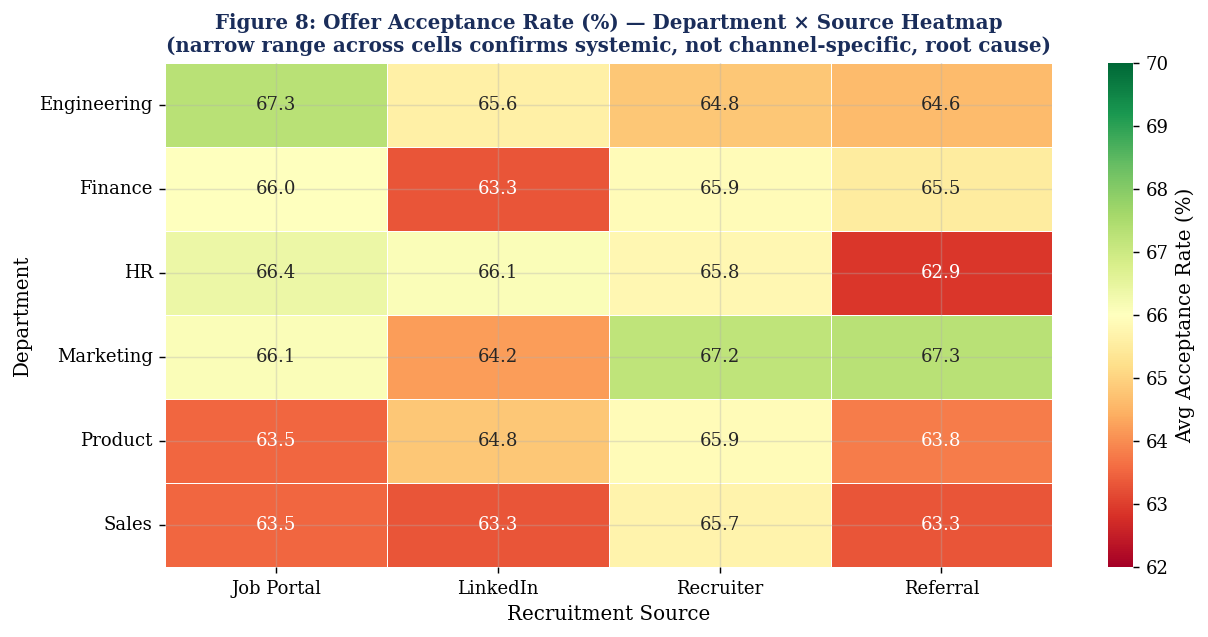

In [17]:
# Department x Source Heatmap
heat = (df.groupby(['department','source'])['offer_acceptance_rate']
         .mean().unstack().round(3)) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.5,
            linecolor='white', vmin=62, vmax=70,
            cbar_kws={'label':'Avg Acceptance Rate (%)'}, ax=ax)
ax.set_title('Figure 8: Offer Acceptance Rate (%) — Department × Source Heatmap\n'
             '(narrow range across cells confirms systemic, not channel-specific, root cause)',
             fontsize=11, fontweight='bold', color=NAVY)
ax.set_xlabel('Recruitment Source'); ax.set_ylabel('Department')
plt.tight_layout()
plt.savefig('fig8_dept_source_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

── Lowest 5 OAR Job Titles
                              oar_%  count
job_title                                 
Sales Representative           62.1    200
Product Manager                62.9    194
Recruitment Specialist         63.2    200
UX Designer                    63.4    233
Business Development Manager   63.7    215

── Highest 5 OAR Job Titles
                      oar_%  count
job_title                         
Marketing Specialist   66.3    217
HR Coordinator         66.7    238
UI Designer            67.6    206
Software Engineer      67.8    209
Content Strategist     68.6    183


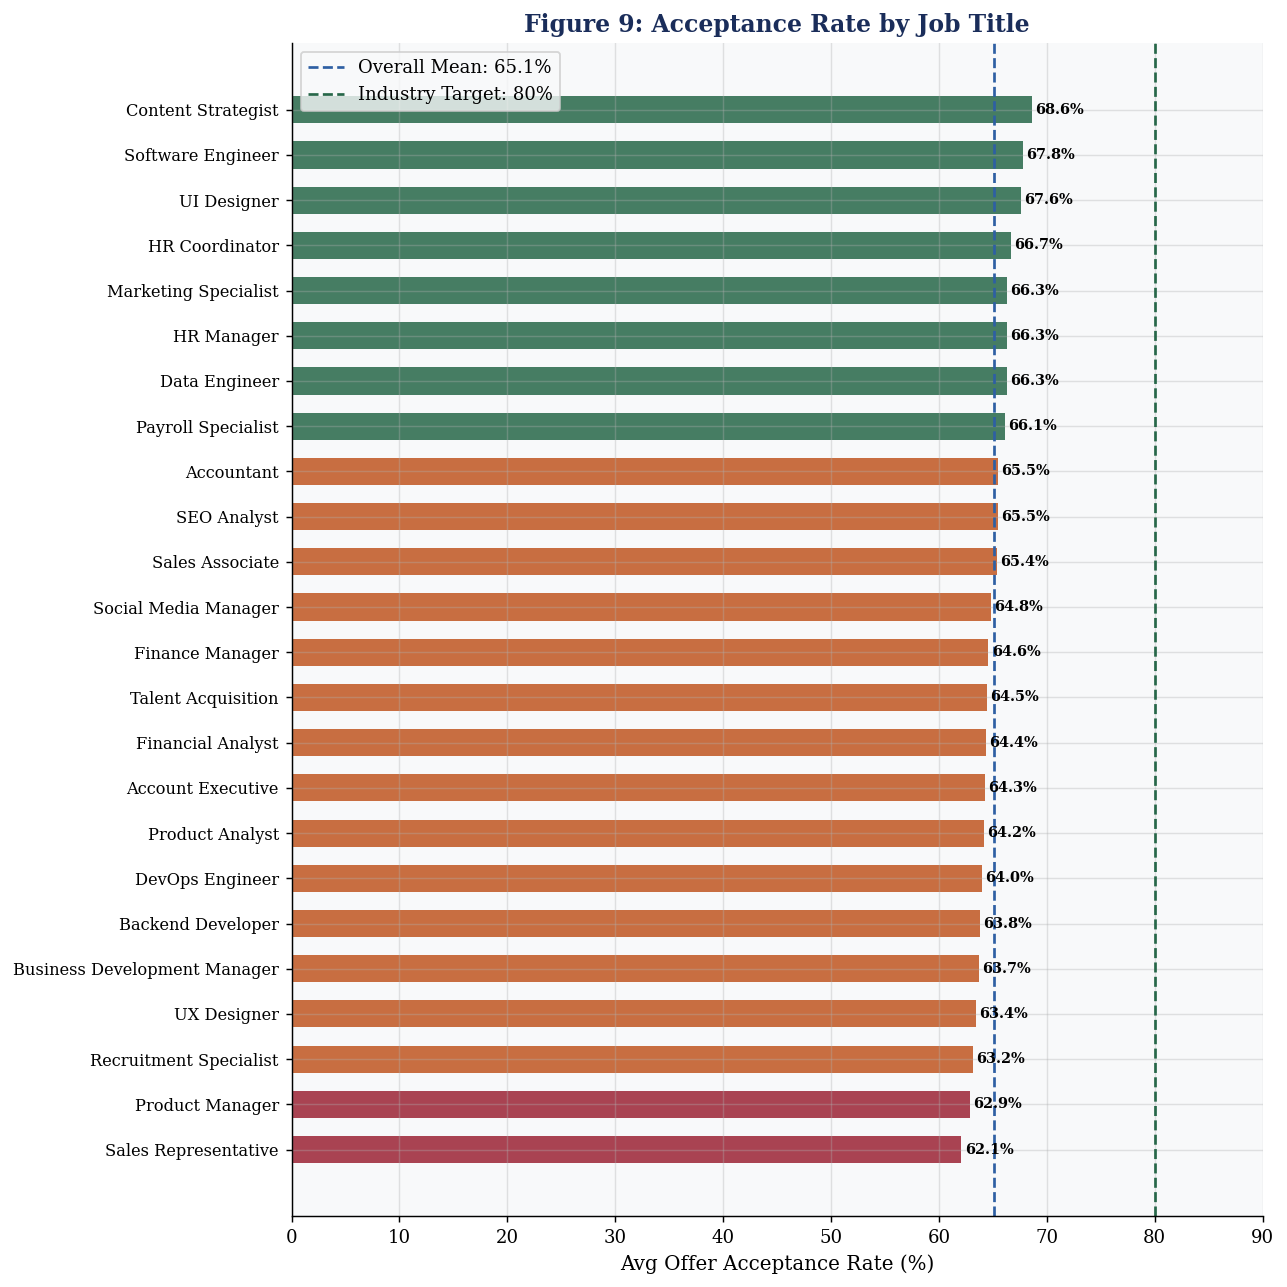

In [18]:
# Job Title Acceptance Extremes
jt = (df.groupby('job_title')['offer_acceptance_rate']
        .agg(['mean', 'count']).sort_values('mean'))
jt['oar_%'] = (jt['mean'] * 100).round(1)

print('── Lowest 5 OAR Job Titles')
print(jt[['oar_%', 'count']].head(5))
print('\n── Highest 5 OAR Job Titles')
print(jt[['oar_%', 'count']].tail(5))

avg_acceptance = df['offer_acceptance_rate'].mean()

colors_bar = [
    RED    if v < 63 else
    ORANGE if v < 66 else
    GREEN
    for v in jt['oar_%']
]

fig, ax = plt.subplots(figsize=(10, 10))

ax.barh(jt.index, jt['oar_%'], color=colors_bar, alpha=0.85, height=0.6)

ax.axvline(avg_acceptance * 100, color=BLUE, linestyle='--',
           linewidth=1.5, label=f'Overall Mean: {avg_acceptance*100:.1f}%')
ax.axvline(80, color=GREEN, linestyle='--',
           linewidth=1.5, label='Industry Target: 80%')

ax.set_xlim(0, 90)

ax.set_yticks(range(len(jt.index)))
ax.set_yticklabels(jt.index, fontsize=9)
ax.set_xlabel('Avg Offer Acceptance Rate (%)', fontsize=11)
ax.set_title('Figure 9: Acceptance Rate by Job Title', fontweight='bold', color=NAVY)

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}%',
        ha='left', va='center',
        fontsize=8, fontweight='bold', color='black'
    )

ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig9_job_title_acceptance.png', bbox_inches='tight', dpi=150)
plt.show()

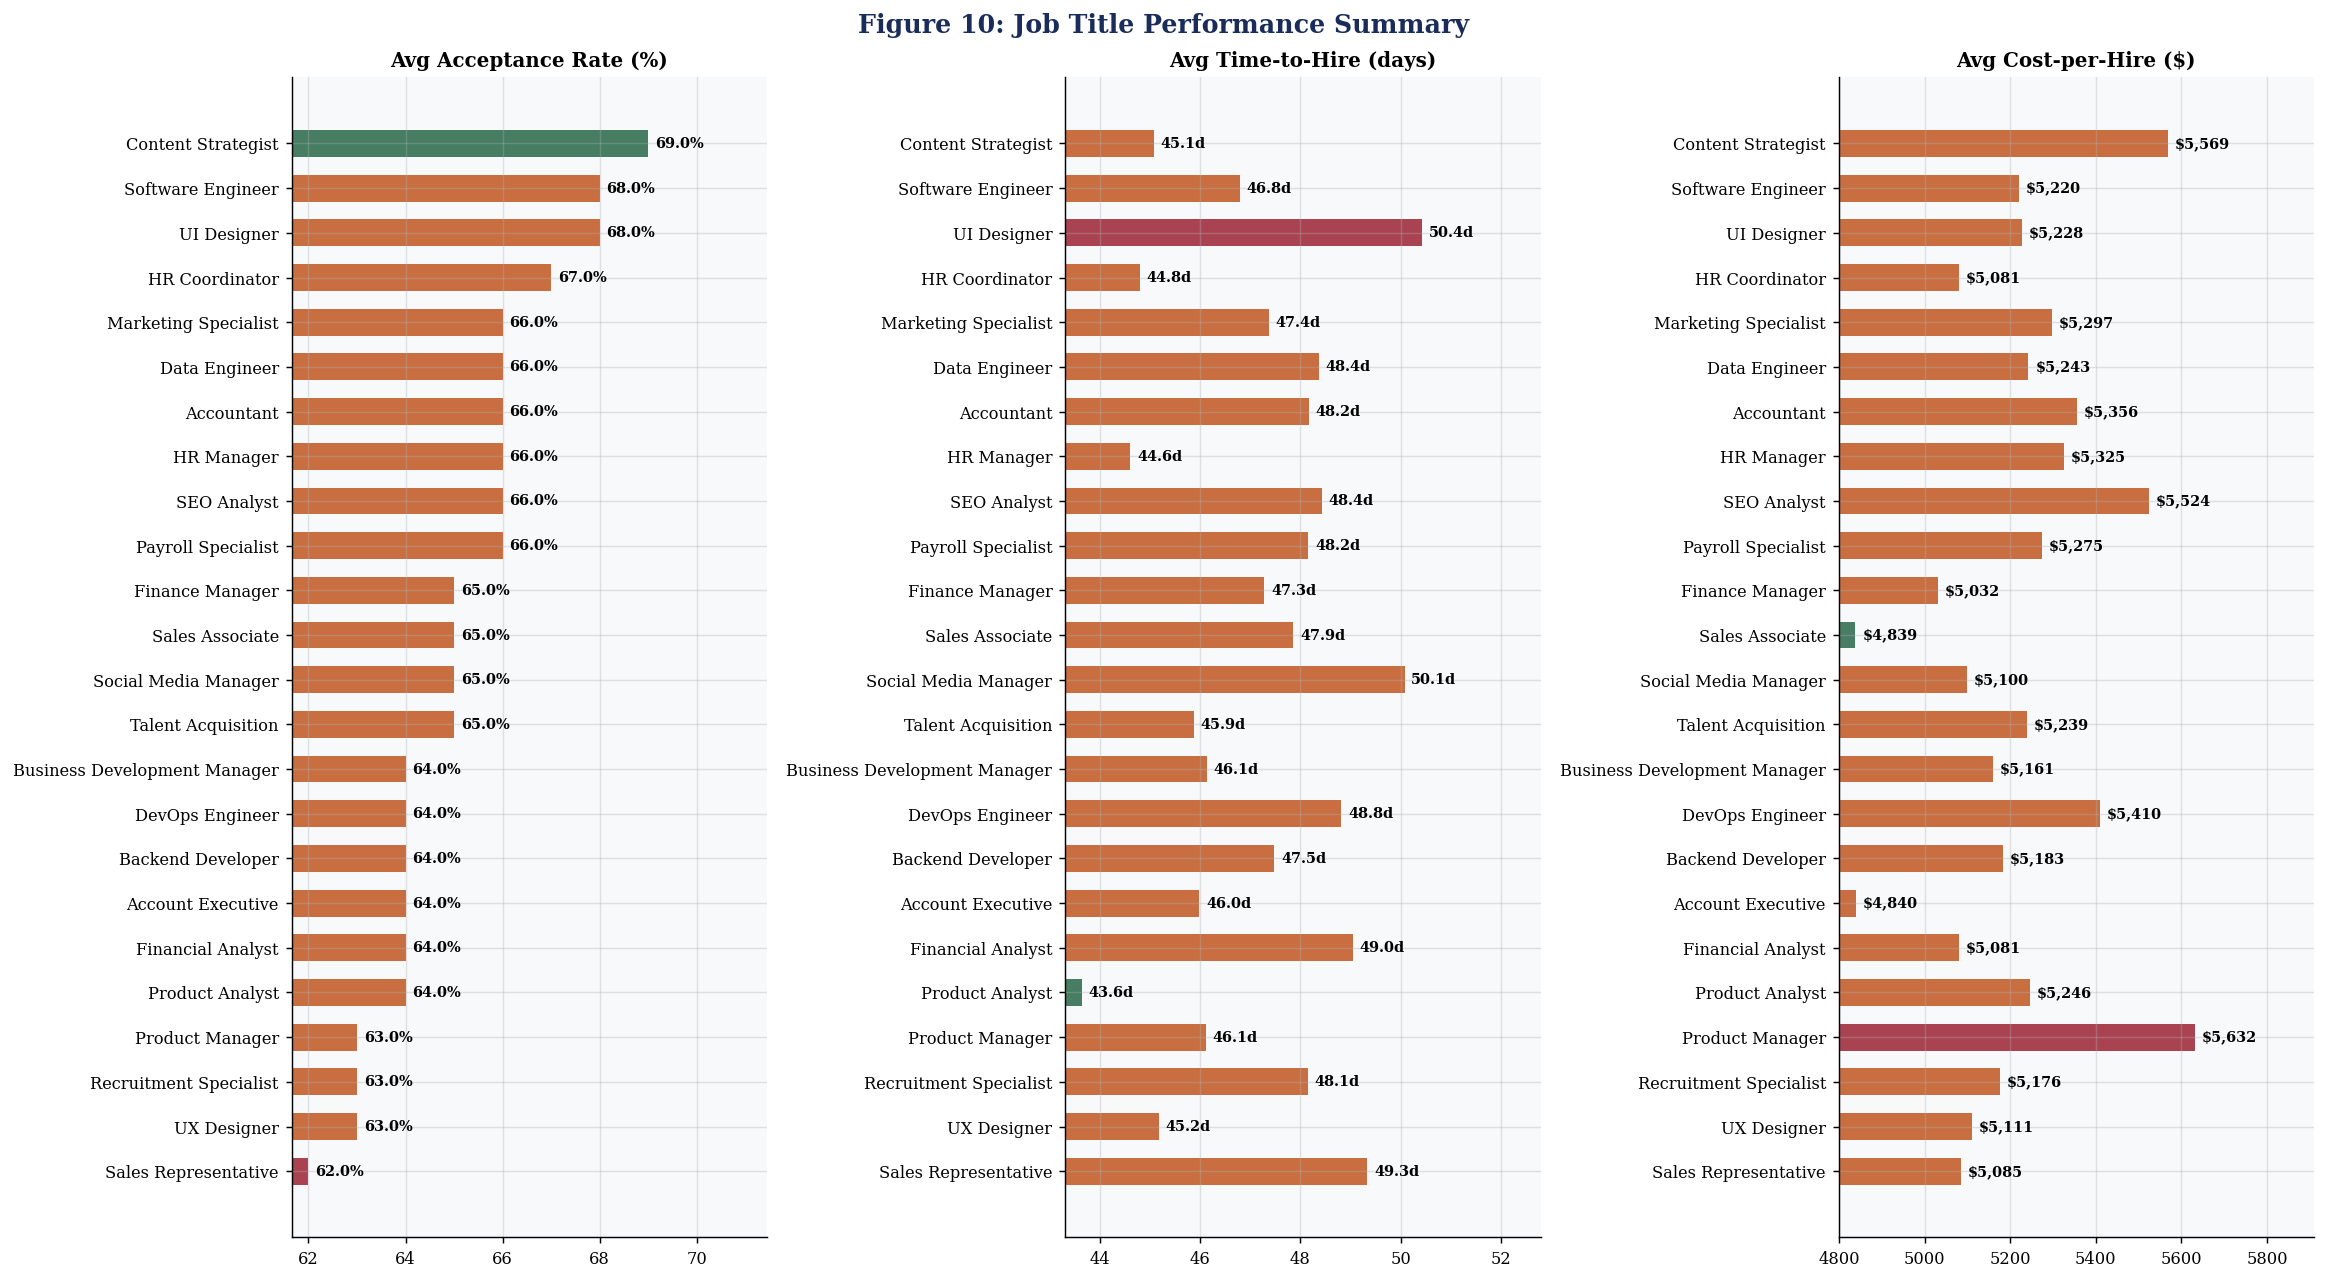

In [20]:
# Job Title Performance Summary
jt_perf = df.groupby('job_title').agg(
    avg_time       = ('time_to_hire_days',    'mean'),
    avg_cost       = ('cost_per_hire',        'mean'),
    avg_acceptance = ('offer_acceptance_rate','mean'),
).round(2).sort_values('avg_acceptance')
jt_perf['oar_%'] = (jt_perf['avg_acceptance'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 10))
fig.suptitle('Figure 10: Job Title Performance Summary',
             fontsize=14, fontweight='bold', color=NAVY)

metrics = [
    ('oar_%',    'Avg Acceptance Rate (%)', '{:.1f}%',  False),
    ('avg_time', 'Avg Time-to-Hire (days)', '{:.1f}d',  True),
    ('avg_cost', 'Avg Cost-per-Hire ($)',   '${:,.0f}', True),
]

for ax, (col, label, fmt, invert) in zip(axes, metrics):
    vals = jt_perf[col]

    if invert:
        colors_bar = [RED if v == vals.max() else GREEN if v == vals.min() else ORANGE
                      for v in vals]
    else:
        colors_bar = [RED if v == vals.min() else GREEN if v == vals.max() else ORANGE
                      for v in vals]

    bars = ax.barh(jt_perf.index, vals, color=colors_bar, alpha=0.85, height=0.6)

    ax.set_title(label, fontweight='bold', fontsize=11)

    span = vals.max() - vals.min()
    ax.set_xlim(vals.min() - span * 0.05, vals.max() + span * 0.35)

    for bar in bars:
        ax.text(
            bar.get_width() + span * 0.02,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(bar.get_width()),
            ha='left', va='center',
            fontsize=8, fontweight='bold', color='black'
        )

    ax.set_yticks(range(len(jt_perf.index)))
    ax.set_yticklabels(jt_perf.index, fontsize=9)
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('fig10_jt_summary.png', bbox_inches='tight', dpi=150)
plt.show()

# 9. Feature Signal Analysis

── Pearson Correlation Matrix
                       num_applicants  time_to_hire_days  cost_per_hire  \
num_applicants                 1.0000            -0.0057         0.0113   
time_to_hire_days             -0.0057             1.0000        -0.0086   
cost_per_hire                  0.0113            -0.0086         1.0000   
offer_acceptance_rate          0.0186            -0.0085        -0.0082   

                       offer_acceptance_rate  
num_applicants                        0.0186  
time_to_hire_days                    -0.0085  
cost_per_hire                        -0.0082  
offer_acceptance_rate                 1.0000  

  Max |r| with OAR: 0.0186
  FINDING: All numeric features have near-zero linear relationship with OAR.
  Implication: predictive signal must come from categorical features or enriched data.


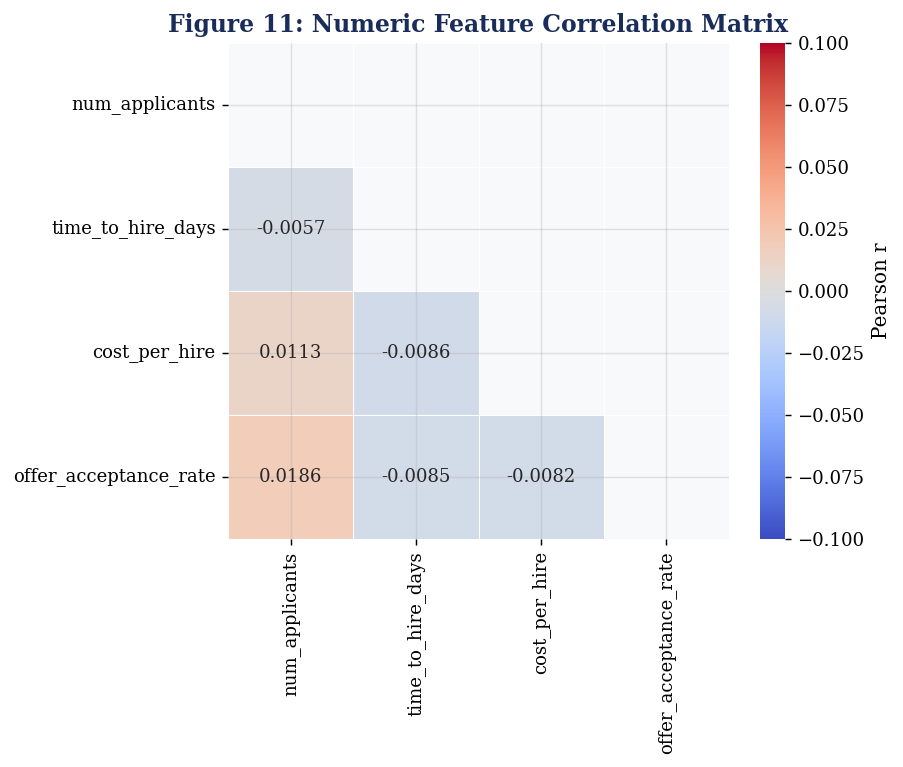

In [21]:
# Pearson Correlation
corr = df[['num_applicants','time_to_hire_days','cost_per_hire','offer_acceptance_rate']].corr()
print('── Pearson Correlation Matrix')
print(corr.round(4))
print(f'\n  Max |r| with OAR: {corr["offer_acceptance_rate"].drop("offer_acceptance_rate").abs().max():.4f}')
print('  FINDING: All numeric features have near-zero linear relationship with OAR.')
print('  Implication: predictive signal must come from categorical features or enriched data.')

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.4f', cmap='coolwarm',
            center=0, vmin=-0.1, vmax=0.1,
            mask=mask, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Figure 11: Numeric Feature Correlation Matrix',
             fontweight='bold', color=NAVY)
plt.tight_layout()
plt.savefig('fig11_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

In [22]:
# ANOVA — Categorical Features
print('── One-Way ANOVA: Categorical Features vs. Offer Acceptance Rate')
for col in ['department', 'source', 'job_title']:
    groups = [df.loc[df[col]==g,'offer_acceptance_rate'].values for g in df[col].unique()]
    f_stat, p_val = stats.f_oneway(*groups)
    grand_mean  = df['offer_acceptance_rate'].mean()
    ss_between  = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups)
    ss_total    = sum((df['offer_acceptance_rate']-grand_mean)**2)
    eta2        = ss_between / ss_total
    sig = '(p<0.05 ✓)' if p_val < 0.05 else '(p>0.05, NOT significant)'
    print(f'  {col:<15}: F={f_stat:.3f}, p={p_val:.4f} {sig}, η²={eta2:.5f}')
print()
print('  FINDING: No categorical feature achieves statistical significance.')
print('  Eta-squared values are negligible (<0.01 = trivially small effect).')

── One-Way ANOVA: Categorical Features vs. Offer Acceptance Rate
  department     : F=1.368, p=0.2332 (p>0.05, NOT significant), η²=0.00137
  source         : F=1.114, p=0.3418 (p>0.05, NOT significant), η²=0.00067
  job_title      : F=1.334, p=0.1315 (p>0.05, NOT significant), η²=0.00613

  FINDING: No categorical feature achieves statistical significance.
  Eta-squared values are negligible (<0.01 = trivially small effect).


In [23]:
# Syntehtic Data Detection
unique_vals = sorted(df['offer_acceptance_rate'].unique())
diffs = [round(unique_vals[i+1]-unique_vals[i], 6) for i in range(len(unique_vals)-1)]

ks_stat, ks_p = stats.kstest(
    df['offer_acceptance_rate'], 'uniform',
    args=(min(unique_vals), max(unique_vals)-min(unique_vals))
)

print('── Synthetic Data Detection Analysis')
print(f'  Unique acceptance rate values : {len(unique_vals)}')
print(f'  Value range                   : {min(unique_vals):.2f} to {max(unique_vals):.2f}')
print(f'  Spacing (std dev of diffs)    : {np.std(diffs):.8f} (perfectly regular)')
print(f'  All spacings equal to         : {diffs[0]:.2f} (consistent 0.01 increments)')
print(f'  KS test vs Uniform dist.      : stat={ks_stat:.4f}, p={ks_p:.4f}')
print(f'  Cannot reject uniformity (p>0.05): {ks_p > 0.05}')
print()
print('  CRITICAL FINDING: The acceptance rate variable exhibits characteristics inconsistent with organically measured data') 
print('  (perfectly regular 0.01 spacing, uniform distribution). This blocks supervised learning on current data.')

── Synthetic Data Detection Analysis
  Unique acceptance rate values : 71
  Value range                   : 0.30 to 1.00
  Spacing (std dev of diffs)    : 0.00000000 (perfectly regular)
  All spacings equal to         : 0.01 (consistent 0.01 increments)
  KS test vs Uniform dist.      : stat=0.0162, p=0.1447
  Cannot reject uniformity (p>0.05): True

  CRITICAL FINDING: The acceptance rate variable exhibits characteristics inconsistent with organically measured data
  (perfectly regular 0.01 spacing, uniform distribution). This blocks supervised learning on current data.


# 10. Gap Analysis vs. Industry Benchmarks

In [28]:
# Quantified Gap Table
benchmarks = {
    'Time-to-Hire (days)'              : {'cur': avg_tth,       'tgt': 36.0,  'lower':True,  'type':'🟢 Industry (LinkedIn 2025)'},
    'Cost-per-Hire ($)'                : {'cur': avg_cph,       'tgt': 4750,  'lower':True,  'type':'🟢 Industry (SHRM 2025)'},
    'Offer Acceptance Rate (%)'        : {'cur': avg_oar,       'tgt': 80.0,  'lower':False, 'type':'🟢 Industry (KPI Depot 2025)'},
}

print(f'{'Metric':<40} {'Current':>10} {'Target':>10} {'Gap':>10} {'Status':<22} {'Benchmark Type'}')
print('─'*120)
for metric, v in benchmarks.items():
    gap = v['cur'] - v['tgt']
    ok  = gap <= 0 if v['lower'] else gap >= 0
    status = '✅ On target' if ok else f'❌ Gap: {gap:+.1f}'
    print(f'{metric:<40} {v["cur"]:>10.1f} {v["tgt"]:>10.1f} {gap:>10.1f} {status:<20} {v["type"]}')

Metric                                      Current     Target        Gap Status                 Benchmark Type
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Time-to-Hire (days)                            47.2       36.0       11.2 ❌ Gap: +11.2         🟢 Industry (LinkedIn 2025)
Cost-per-Hire ($)                            5214.8     4750.0      464.8 ❌ Gap: +464.8        🟢 Industry (SHRM 2025)
Offer Acceptance Rate (%)                      65.1       80.0      -14.9 ❌ Gap: -14.9         🟢 Industry (KPI Depot 2025)


In [25]:
# Business Impact Quantification
annual_hires = 5000

cost_overrun       = (avg_cph - 4750) * annual_hires
excess_low_accept  = max(0, low_n - int(annual_hires * 0.2))
rework_waste       = excess_low_accept * 2000
vacancy_savings    = (avg_tth - 30) * 300 * 1000
total_value        = cost_overrun + rework_waste + vacancy_savings
investment_cost    = 120_000
roi_multiplier     = total_value / investment_cost

print('── Quantified Business Impact')
print(f'  Annual hires assumed (= dataset N)        : {annual_hires:,}')
print(f'  Cost overrun per hire: ${avg_cph-4750:,.0f} × {annual_hires:,}       : ${cost_overrun:,.0f}')
print(f'  Excess low-accept hires above 20% tgt     : {excess_low_accept:,}')
print(f'  Rework waste ({excess_low_accept:,} × $2,000)             : ${rework_waste:,.0f}')
print(f'  Vacancy cost ({avg_tth-30:.1f}d × $300 × 1,000 roles) : ${vacancy_savings:,.0f}')
print(f'  ────────────────────────────────────────────────────────')
print(f'  TOTAL ESTIMATED ANNUAL VALUE              : ${total_value:,.0f}')
print(f'  Estimated project investment              : ${investment_cost:,}')
print(f'  ROI (conservative estimate)               : {roi_multiplier:.0f}x')

── Quantified Business Impact
  Annual hires assumed (= dataset N)        : 5,000
  Cost overrun per hire: $465 × 5,000       : $2,324,131
  Excess low-accept hires above 20% tgt     : 1,825
  Rework waste (1,825 × $2,000)             : $3,650,000
  Vacancy cost (17.2d × $300 × 1,000 roles) : $5,157,420
  ────────────────────────────────────────────────────────
  TOTAL ESTIMATED ANNUAL VALUE              : $11,131,551
  Estimated project investment              : $120,000
  ROI (conservative estimate)               : 93x
